## EXO - ESTIMATION D'UNE FREQUENCE COMPLEXE

In [2]:
# Librairies à importer

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

In [3]:
#  PARAMÈTRES

A      = 1.0
phi    = 0.5
omega0_ref = 1.0  # Pulsation de référence
N      = 20
N_MC   = 1000
SNR_dB = 10.0

# Grille de recherche pour l'EMV (Périodogramme)
omega_grid = np.linspace(-np.pi, np.pi, 1000)

In [5]:
#  FONCTIONS

def generer_signal(N, omega_true, sigma):
    n     = np.arange(N)
    s     = A * np.exp(1j * (n * omega_true + phi))
    bruit = (sigma / np.sqrt(2)) * (np.random.randn(N) + 1j * np.random.randn(N))
    return s + bruit

def estimer_omega(x):
    n = np.arange(len(x))
    
    # -- Partie 1 : Recherche sur grille --
    # On cherche le meilleur point sur la grille de 1000 points
    vals = np.abs(np.dot(x, np.exp(-1j * np.outer(n, omega_grid))))**2
    idx_max = np.argmax(vals)
    omega_initial = omega_grid[idx_max]
    
    # -- Partie 2 : Raffinement local (Recherche continue) --
    # On définit la fonction de coût à MINIMISER (donc -Périodogramme)
    def objective(w):
        return -np.abs(np.sum(x * np.exp(-1j * n * w)))**2
    
    # On cherche le minimum de 'objective' autour de omega_initial
    # On définit un intervalle de recherche très petit (le pas de la grille)
    pas = (omega_grid[1] - omega_grid[0])
    res = minimize_scalar(objective, 
                          bounds=(omega_initial - pas, omega_initial + pas), 
                          method='bounded')
    
    return res.x

def estimer_phi(x, omega):
    n = np.arange(len(x))
    projection = np.sum(x * np.exp(-1j * n * omega))
    return np.angle(projection)

def BCR(N, sigma):
    return (sigma**2 / A**2) * 6 / (N * (N**2 - 1))

def monte_carlo(N, omega_true, sigma):
    estimations = []
    for _ in range(N_MC):
        x = generer_signal(N, omega_true, sigma)
        omega_hat = estimer_omega(x)
        estimations.append(omega_hat)

    estimations = np.array(estimations)
    biais       = np.mean(estimations) - omega_true
    variance    = np.var(estimations)
    mse         = np.mean((estimations - omega_true) ** 2)
    return biais, variance, mse

def tracer(ax, x, y, bcr, xlabel, ylabel, title):
    ax.semilogy(x, y,   'o-', label=ylabel)
    if np.isscalar(bcr):
        ax.axhline(y=bcr, color='r', linestyle='--', label='BCR')
    else:
        ax.semilogy(x, bcr, 'r--', label='BCR')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which='both', alpha=0.4)

def mce_theo_pulsation(bcr_classique):
    # bcr_classique est la valeur sigma^2 / (2 * N * A^2) ou celle de omega
    return 2 - (2 / np.sqrt(1 + bcr_classique))

def estimer_signal_complet(x):
    n = np.arange(len(x))
    
    # 1. On récupère la pulsation (ton code existant)
    omega_hat = estimer_omega(x)
    
    # 2. Estimation conjointe de A et phi via la projection complexe
    projection = np.mean(x * np.exp(-1j * n * omega_hat))
    
    A_hat = np.abs(projection)
    phi_hat = np.angle(projection)
    
    # 3. Reconstruction du signal
    s_hat = A_hat * np.exp(1j * (n * omega_hat + phi_hat))
    
    return s_hat, (A_hat, omega_hat, phi_hat)


Sweep SNR...


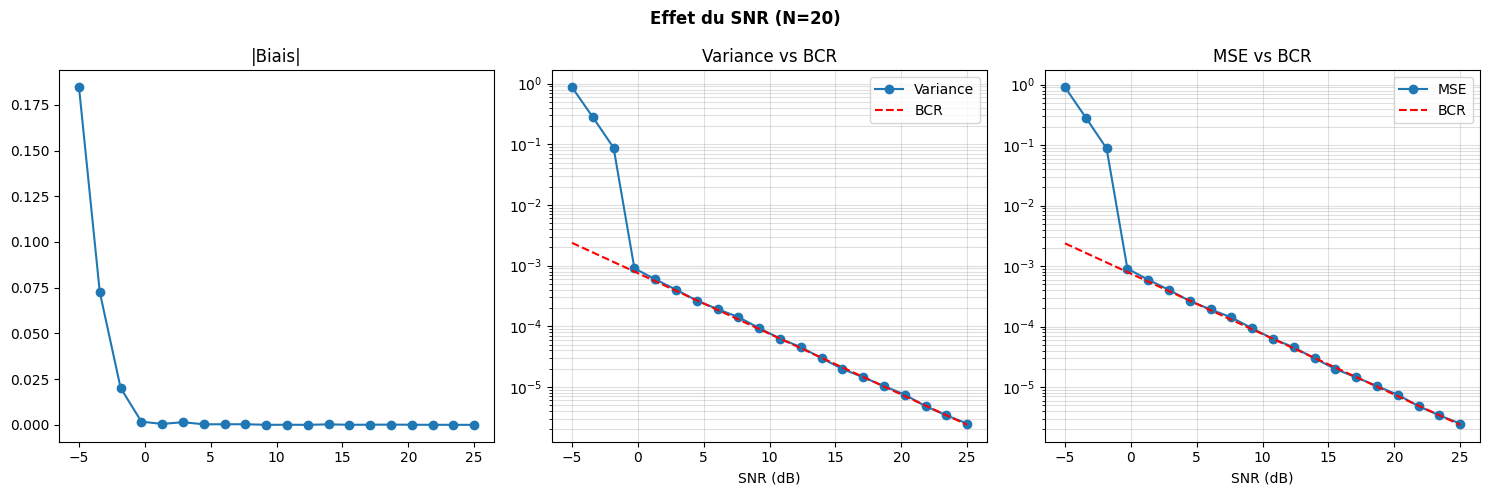

In [4]:
# Premier tracé

SNR_dB_values = np.linspace(-5, 25, 20)
biais_snr, variance_snr, mse_snr, bcr_snr = [], [], [], []

print("Sweep SNR...")
for snr_db in SNR_dB_values:
    snr   = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    b, v, m = monte_carlo(N, omega0_ref, sigma)
    biais_snr.append(abs(b))
    variance_snr.append(v)
    mse_snr.append(m)
    bcr_snr.append(BCR(N, sigma))

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
fig1.suptitle(f"Effet du SNR (N={N})", fontweight='bold')

axes1[0].plot(SNR_dB_values, biais_snr, 'o-')
axes1[0].set_title("|Biais|")

tracer(axes1[1], SNR_dB_values, variance_snr, bcr_snr, "SNR (dB)", "Variance", "Variance vs BCR")
tracer(axes1[2], SNR_dB_values, mse_snr, bcr_snr, "SNR (dB)", "MSE", "MSE vs BCR")

fig1.tight_layout()
plt.show() 

Sweep N...


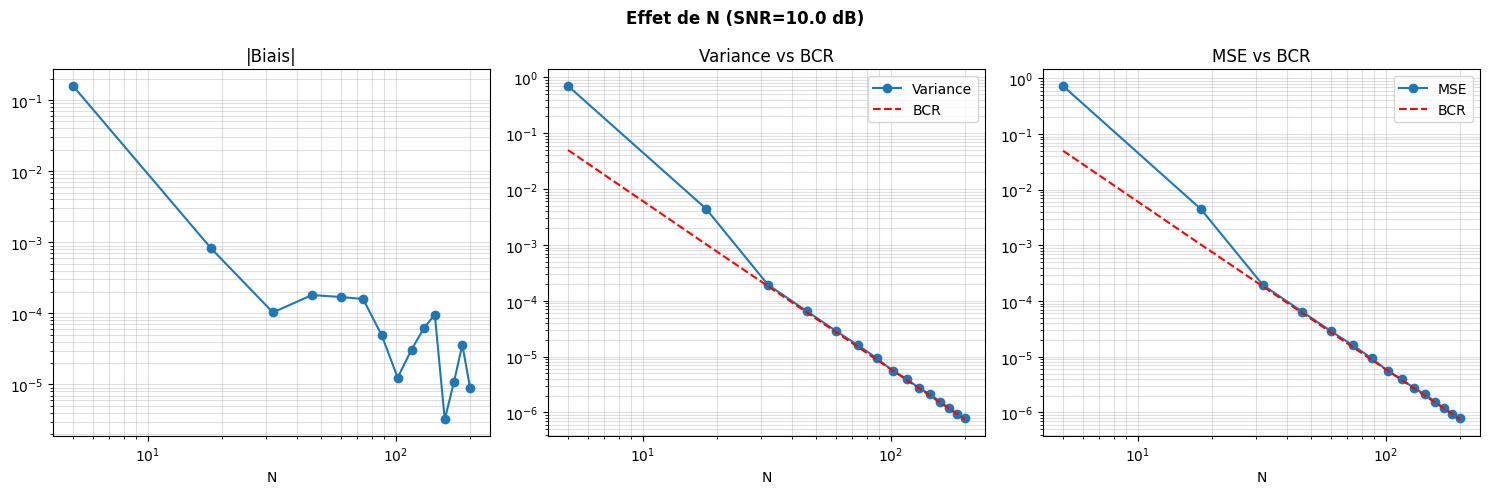

In [5]:
# Deuxième tracé

N_values = np.unique(np.linspace(5, 200, 15).astype(int))

snr_ref_N  = 10 ** (0 / 10)
sigma_ref_N = np.sqrt(A**2 / snr_ref_N)
biais_N, variance_N, mse_N, bcr_N = [], [], [], []

print("Sweep N...")
for Nv in N_values:
   
    b, v, m = monte_carlo(Nv, omega0_ref, sigma_ref_N)
    biais_N.append(abs(b))
    variance_N.append(v)
    mse_N.append(m)
    bcr_N.append(BCR(Nv, sigma_ref_N))

# -- Visualisation --
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle(f"Effet de N (SNR={SNR_dB} dB)", fontweight='bold')

# Biais en log-log
axes2[0].loglog(N_values, biais_N, 'o-', label="|Biais|")
axes2[0].set_title("|Biais|")
axes2[0].set_xlabel("N")
axes2[0].grid(True, which='both', alpha=0.4)

# Variance vs BCR en log-log
tracer(axes2[1], N_values, variance_N, bcr_N, "N", "Variance", "Variance vs BCR")
axes2[1].set_xscale('log') 
axes2[1].set_yscale('log') 

# MSE vs BCR en log-log
tracer(axes2[2], N_values, mse_N, bcr_N, "N", "MSE", "MSE vs BCR")
axes2[2].set_xscale('log')
axes2[2].set_yscale('log')

fig2.tight_layout()
plt.show()

In [ ]:
# Troisème tracé

omega_values = np.concatenate([
    np.linspace(-np.pi, 0.8, 15),
    np.linspace(0.9, 1.1, 5), 
    np.linspace(1.2, np.pi, 15)
])
omega_values = np.sort(omega_values)

snr_ref_W = 10 ** (5 / 10) # SNR fixé à 5 dB
sigma_ref_W = np.sqrt(A**2 / snr_ref_W)
biais_W, variance_W, mse_W, bcr_val = [], [], [], BCR(N, sigma_ref_W)

print("Sweep Omega (SNR = 5 dB)...")
for wv in omega_values:
    b, v, m = monte_carlo(N, wv, sigma_ref_W)
    biais_W.append(abs(b))
    variance_W.append(v)
    mse_W.append(m)
fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5))
fig3.suptitle(f"Effet de la Pulsation (SNR=5 dB, N={N})", fontweight='bold')

# Affichage du Biais
axes3[0].plot(omega_values, biais_W, 'o-')
axes3[0].set_title("|Biais|")
axes3[0].set_xlabel(r"$\omega_0$")
axes3[0].grid(True, alpha=0.4)

# Variance vs BCR
tracer(axes3[1], omega_values, variance_W, bcr_val, r"$\omega_0$", "Variance", "Variance vs BCR")

# MSE vs BCR
tracer(axes3[2], omega_values, mse_W, bcr_val, r"$\omega_0$", "MSE", "MSE vs BCR")

fig3.tight_layout()
plt.show() # Affiche la figure directement sous la cellule


Sweep Omega (SNR = 5 dB)...


Calcul de la MSE


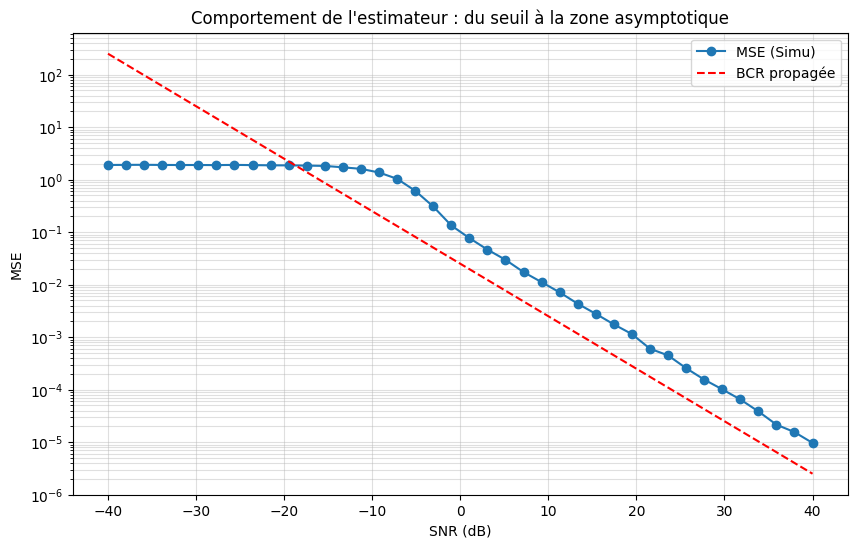

In [ ]:
#  MSE DE RECONSTRUCTION 

SNR_dB_range = np.linspace(-40, 40, 40) 
mse_estimation_pure = []
bcr_propagation_signal = []

print("Calcul de la MSE")

for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    errors_iter = []
    n = np.arange(N)
    s_vrai = A * np.exp(1j * (n * omega0_ref + phi))
    
    for _ in range(N_MC):
        x = generer_signal(N, omega0_ref, sigma)
        omega_hat = estimer_omega(x)
        

        s_hat = A * np.exp(1j * (n * omega_hat + phi))
        errors_iter.append(np.mean(np.abs(s_vrai - s_hat)**2))
    
    mse_estimation_pure.append(np.mean(errors_iter))
    

    borne_sig = (sigma**2) / (2*N)
    bcr_propagation_signal.append(borne_sig)

# --- Affichage ---
fig5, ax5 = plt.subplots(1, 1, figsize=(10, 6))
ax5.semilogy(SNR_dB_range, mse_estimation_pure, 'o-', label="MSE (Simu)")
ax5.semilogy(SNR_dB_range, bcr_propagation_signal, 'r--', label="BCR propagée")


ax5.set_xlabel("SNR (dB)")
ax5.set_ylabel("MSE")
ax5.set_title("Comportement de l'estimateur : du seuil à la zone asymptotique")
ax5.legend()
ax5.grid(True, which='both', alpha=0.4)

plt.show()

Calcul de la MCE du signal en cours...


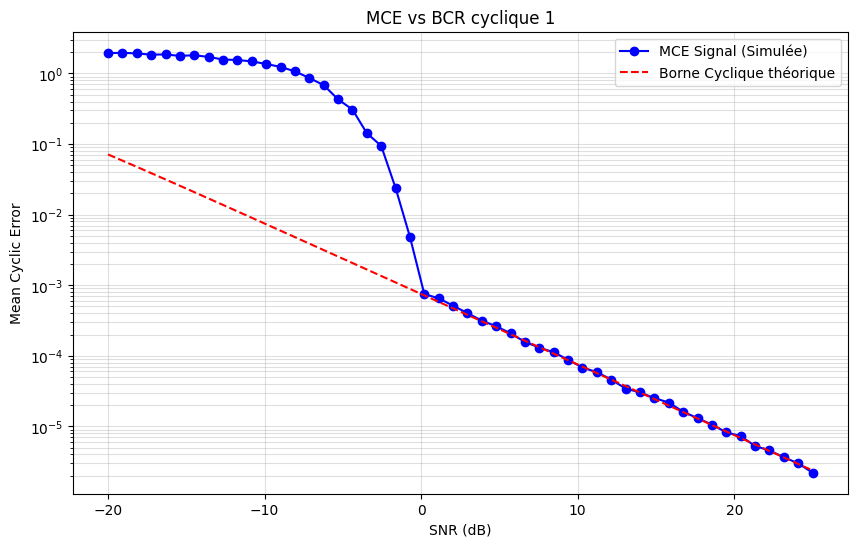

In [35]:
# Tracé de la MCE et de la BCR cyclique 1 pour l'estimation de la pulsation

SNR_dB_range = np.linspace(-20, 25, 50) 

mce_simu_sig = []
borne_cyclique_sig = []

print("Calcul de la MCE du signal en cours...")

for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    errors_iter = []
    n = np.arange(N)

    s_vrai = A * np.exp(1j * (n * omega0_ref + phi))
    
    for _ in range(N_MC):

        x = generer_signal(N, omega0_ref, sigma)
        omega_hat = estimer_omega(x)
        

        s_hat = A * np.exp(1j * (n * omega_hat + phi))
        
        dist_sq = np.mean(np.abs(s_vrai - s_hat)**2)

        mce = np.mean(2 * (1 - np.cos(omega_hat - omega0_ref)))

        errors_iter.append(mce)
        
    
    mce_simu_sig.append(np.mean(errors_iter))
    

    
    bcr_omega = (sigma**2 / A**2) * 6 / (N * (N**2 - 1))
    bcr_cyclique = 2 - 2 / np.sqrt(1 + bcr_omega)


    borne_cyclique_sig.append(bcr_cyclique)

# --- Affichage ---
plt.figure(figsize=(10, 6))
plt.semilogy(SNR_dB_range, mce_simu_sig, 'bo-', label='MCE Signal (Simulée)')
plt.semilogy(SNR_dB_range, borne_cyclique_sig, 'r--', label='Borne Cyclique théorique')

plt.xlabel('SNR (dB)')
plt.ylabel('Mean Cyclic Error')
plt.title('MCE vs BCR cyclique 1')
plt.grid(True, which='both', alpha=0.4)
plt.legend()
plt.show()

Calcul de la MSE


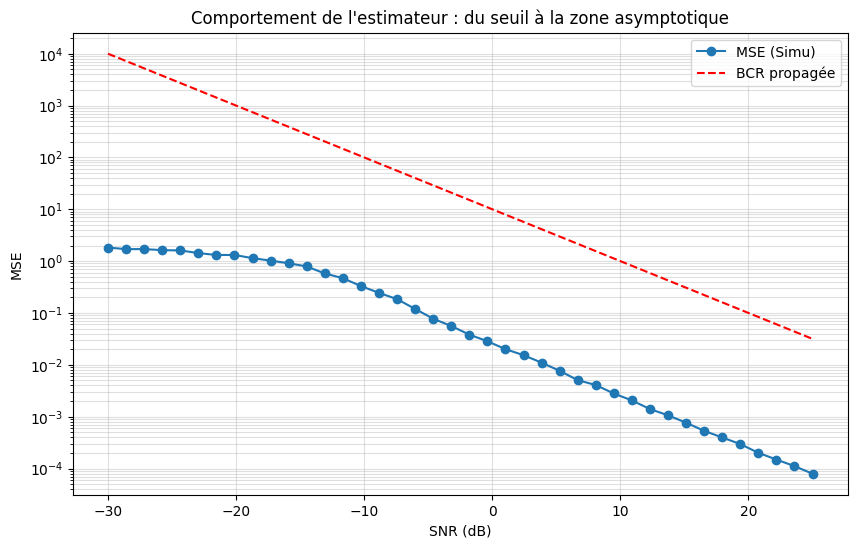

In [ ]:
#  MSE DE RECONSTRUCTION 

SNR_dB_range = np.linspace(-30, 25, 40) 
mse_estimation_pure = []
bcr_propagation_signal = []

print("Calcul de la MSE")

for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    errors_iter = []
    n = np.arange(N)
    s_vrai = A * np.exp(1j * (n * omega0_ref + phi))
    
    for _ in range(N_MC):
        x = generer_signal(N, omega0_ref, sigma)
        phi_hat = estimer_phi(x, omega0_ref)
        

        s_hat = A * np.exp(1j * (n * omega0_ref + phi_hat))
        errors_iter.append(np.mean(np.abs(s_vrai - s_hat)**2))
    
    mse_estimation_pure.append(np.mean(errors_iter))
    
    borne_propagee = (sigma**2) / 2*N
    bcr_propagation_signal.append(borne_propagee)

# --- Affichage ---
fig6, ax6 = plt.subplots(1, 1, figsize=(10, 6))
ax6.semilogy(SNR_dB_range, mse_estimation_pure, 'o-', label="MSE (Simu)")
ax6.semilogy(SNR_dB_range, bcr_propagation_signal, 'r--', label="BCR propagée")


ax6.set_xlabel("SNR (dB)")
ax6.set_ylabel("MSE")
ax6.set_title("Comportement de l'estimateur : du seuil à la zone asymptotique")
ax6.legend()
ax6.grid(True, which='both', alpha=0.4)

plt.show()

Calcul de la MCE du signal en cours...


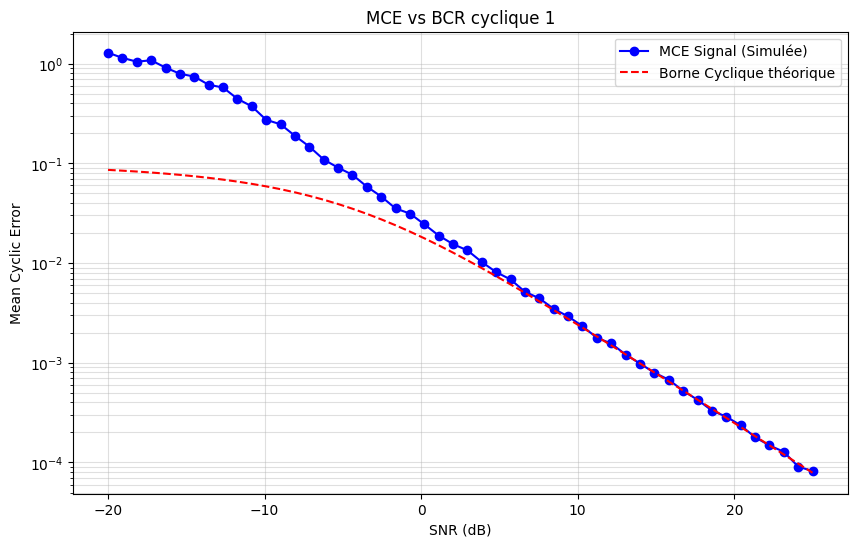

In [ ]:
# Tracé de la MCE et de la BCR cyclique dans le cas de l'estimation de la phase

SNR_dB_range = np.linspace(-20, 25, 50) 

mce_simu_sig = []
borne_cyclique_sig = []

print("Calcul de la MCE du signal en cours...")

for snr_db in SNR_dB_range:
    snr = 10 ** (snr_db / 10)
    sigma = np.sqrt(A**2 / snr)
    
    errors_iter = []
    n = np.arange(N)

    s_vrai = A * np.exp(1j * (n * omega0_ref + phi))
    
    for _ in range(N_MC):

        x = generer_signal(N, omega0_ref, sigma)
        phi_hat = estimer_phi(x, omega0_ref)
        
        s_hat = A * np.exp(1j * (n * omega0_ref + phi_hat))
        mce = np.mean(2 * (1 - np.cos(phi_hat - phi)))

        errors_iter.append(mce)
    
    mce_simu_sig.append(np.mean(errors_iter))
    
    bcr_sig_classique = (sigma**2) / 2
    

    val_borne = (2 - 2 / np.sqrt(1 + bcr_sig_classique))/N
    borne_cyclique_sig.append(val_borne)


plt.figure(figsize=(10, 6))
plt.semilogy(SNR_dB_range, mce_simu_sig, 'bo-', label='MCE Signal')
plt.semilogy(SNR_dB_range, borne_cyclique_sig, 'r--', label='Borne Cyclique théorique')

plt.xlabel('SNR (dB)')
plt.ylabel('Mean Cyclic Error')
plt.title('MCE vs BCR cyclique 1')
plt.grid(True, which='both', alpha=0.4)
plt.legend()
plt.show()